In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import netCDF4 as nc

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import phys_grad, compute_core_mean, add_region_column


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [3]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_eddies = add_region_column(
    df_eddies,
    X_grid, Y_grid,
    lon_rho, lat_rho,
    h, mask_rho
)
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,118.032741,47.992205,1.434563,74.597458,38,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,U2
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,115.905401,50.858737,1.417135,76.449111,38,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,U2
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,113.778061,53.725269,1.413542,78.300764,38,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,U2
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,111.650721,56.591801,1.411879,69.625773,38,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976810,184.917206,U2
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,115.925719,57.471319,1.597888,72.613632,38,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.067059,181.174121,U2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125221,2929,10646,CE,153.739453,-37.488262,181,61,515.983450,302.961328,-0.000026,...,61.312206,19.408106,1.110214,55.409919,28,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,0.752304,4.278123,D1
125222,2929,10647,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,61.305207,19.388829,1.037331,44.896186,28,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,1.165623,28.370419,D1
125223,2929,10648,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000021,...,61.298208,19.369553,1.055789,38.796956,28,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
125224,2929,10649,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000019,...,64.546558,19.604126,1.070344,40.028670,28,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1


In [4]:
df_eddies['f'] = f[df_eddies.ic, df_eddies.jc]
# df_eddies['h'] = h[df_eddies.ic, df_eddies.jc]
df_eddies = compute_core_mean(
    df_eddies, X_grid, Y_grid, mask_rho,
    fixed_field=h,
    colname="h"
)

dhdx, dhdy = phys_grad(h, X_grid*1e3, Y_grid*1e3, mask_rho)
dh_dN = -(np.sin(angle) * dhdx + np.cos(angle) * dhdy)
dh_dE = -(np.cos(angle) * dhdx - np.sin(angle) * dhdy)

# df_eddies['dhdx'] = dh_dE[df_eddies.ic, df_eddies.jc]
# df_eddies['dhdy'] = dh_dN[df_eddies.ic, df_eddies.jc]
df_eddies = compute_core_mean(
    df_eddies, X_grid, Y_grid, mask_rho,
    fixed_field=dh_dE,
    colname="dhdx"
)
df_eddies = compute_core_mean(
    df_eddies, X_grid, Y_grid, mask_rho,
    fixed_field=dh_dN,
    colname="dhdy"
)

dfdx, dfdy = phys_grad(f, X_grid*1e3, Y_grid*1e3, mask_rho)
df_dN = -(np.sin(angle) * dfdx + np.cos(angle) * dfdy)

df_eddies['beta'] = df_dN[df_eddies.ic, df_eddies.jc]


In [5]:
omega_f = df_eddies['w'] + df_eddies['f']

# -----------------------------
# Planetary component
# -----------------------------

df_eddies['PV_grad_plan_x'] = 0

df_eddies['PV_grad_plan_y'] = (
    df_eddies['beta']
    / df_eddies['h']
)

# -----------------------------
# Topographic component
# -----------------------------

df_eddies['PV_grad_topo_x'] = (
    -(omega_f)
    * df_eddies['dhdx']
    / df_eddies['h']**2
)

df_eddies['PV_grad_topo_y'] = (
    -(omega_f)
    * df_eddies['dhdy']
    / df_eddies['h']**2
)

# -----------------------------
# Total PV gradient
# -----------------------------

df_eddies['PV_grad_x'] = (
    df_eddies['PV_grad_plan_x']
    + df_eddies['PV_grad_topo_x']
)

df_eddies['PV_grad_y'] = (
    df_eddies['PV_grad_plan_y']
    + df_eddies['PV_grad_topo_y']
)

# -----------------------------
# Magnitudes
# -----------------------------

df_eddies['PV_grad_plan_mag'] = np.hypot(
    df_eddies['PV_grad_plan_x'],
    df_eddies['PV_grad_plan_y']
)

df_eddies['PV_grad_topo_mag'] = np.hypot(
    df_eddies['PV_grad_topo_x'],
    df_eddies['PV_grad_topo_y']
)

df_eddies['PV_grad_mag'] = np.hypot(
    df_eddies['PV_grad_x'],
    df_eddies['PV_grad_y']
)

# -----------------------------
# Bearings
# 0° = north
# 90° = east
# -----------------------------

def bearing_from_xy(x, y):
    return (90 - np.degrees(np.arctan2(y, x))) % 360

df_eddies['PV_grad_plan_theta'] = bearing_from_xy(
    df_eddies['PV_grad_plan_x'],
    df_eddies['PV_grad_plan_y']
)

df_eddies['PV_grad_topo_theta'] = bearing_from_xy(
    df_eddies['PV_grad_topo_x'],
    df_eddies['PV_grad_topo_y']
)

df_eddies['PV_grad_theta'] = bearing_from_xy(
    df_eddies['PV_grad_x'],
    df_eddies['PV_grad_y']
)

In [6]:
def angle_diff_180(a, b):
    """
    Absolute angular difference between two bearings in degrees.
    Returns values in [0, 180].
    """
    return np.abs((a - b + 180) % 360 - 180)


df_eddies['dtheta_PV_grad'] = angle_diff_180(
    df_eddies['TiltDir'],
    df_eddies['PV_grad_theta']
)

df_eddies['dtheta_PV_grad_topo'] = angle_diff_180(
    df_eddies['TiltDir'],
    df_eddies['PV_grad_topo_theta']
)

df_eddies['dtheta_PV_grad_plan'] = angle_diff_180(
    df_eddies['TiltDir'],
    df_eddies['PV_grad_plan_theta']
)

In [7]:
def point_b(a, r, theta_deg):
    theta_rad = np.radians(theta_deg)
    dx = r * np.sin(theta_rad)
    dy = r * np.cos(theta_rad)
    return a[0] - dx, a[1] - dy

def plotter(eddy, pad=50, ax=None, scatter=False, cbar=False,
            quiver_scale=None, tilt_offset=0, tilt_clr='limegreen', quiver_width=None,
            alpha=.8, s=5, c='w'):

    df = df_eddies[df_eddies.Eddy == eddy].copy()

    if df.empty:
        raise ValueError(f'Eddy {eddy} not found')

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    # Bathymetry
    m = ax.contourf(
        X_grid, Y_grid,
        np.where(mask_rho, h / 1e3, np.nan),
        cmap='grey',
        zorder=0
    )

    # Optional PV gradient magnitude scatter
    if scatter:
        # sc = ax.scatter(
        #     df.xc, df.yc,
        #     c=df.PV_grad_mag,
        #     cmap='plasma',
        #     edgecolor='k',
        #     s=30,
        #     zorder=4
        # )
        # fig.colorbar(sc, ax=ax, label=r'$|\nabla PV|$')
        ax.scatter(
            df.xc, df.yc,
            c=c,
            # edgecolor='w',
            s=s,
            zorder=4
        )

    # Optional bathymetry colourbar
    if cbar:
        fig.colorbar(m, ax=ax, label='Depth (km)', location='top')

    # Colour by cyclonicity
    clr = 'c' if df.iloc[0].Cyc == 'CE' else 'r'

    # PV-gradient vectors
    ax.quiver(
        df.xc, df.yc,
        df.PV_grad_x, df.PV_grad_y,
        color=tilt_clr,
        scale=quiver_scale,
        width=quiver_width,
        zorder=3,
        alpha=alpha
    )

    # Tilt vectors
    for _, row in df.dropna(subset=['xc', 'yc', 'TiltDis', 'TiltDir']).iterrows():

        x0 = row.xc
        y0 = row.yc

        xb, yb = point_b(
            [x0, y0],
            row.TiltDis,
            (row.TiltDir + tilt_offset) % 360
        )

        ax.plot(
            [x0, xb],
            [y0, yb],
            color=clr,
            lw=1.5,
            zorder=2,
            alpha=alpha
        )

    # # Track line
    # ax.plot(
    #     df.xc, df.yc,
    #     color='k',
    #     lw=1,
    #     alpha=0.7,
    #     zorder=1
    # )

    # # Start/end markers
    # ax.scatter(df.xc.iloc[0], df.yc.iloc[0], c='lime', s=50, zorder=5, label='start')
    # ax.scatter(df.xc.iloc[-1], df.yc.iloc[-1], c='yellow', s=50, zorder=5, label='end')

    ax.set_xlim(df.xc.min() - pad, df.xc.max() + pad)
    ax.set_ylim(df.yc.min() - pad, df.yc.max() + pad)

    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'Eddy {eddy} ({df.iloc[0].Cyc})')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')

    return fig, ax
        

In [8]:
# Mean angle for each eddy
ae_means = (
    df_eddies[df_eddies.Cyc == 'AE']
    .groupby('Eddy')['dtheta_PV_grad']
    .mean()
)

ce_means = (
    df_eddies[df_eddies.Cyc == 'CE']
    .groupby('Eddy')['dtheta_PV_grad']
    .mean()
)

# Top 10 closest to the maximum (AE)
ae_top10 = ae_means.sort_values(ascending=False).head(45).index

# Top 10 closest to the minimum (CE)
ce_top10 = ce_means.sort_values(ascending=True).head(45).index

print("AE:")
print(ae_top10)

print("\nCE:")
print(ce_top10)

AE:
Index([ 331,  494,   99, 2560, 2154,  575,  994,   14,  774, 1410, 2266,  322,
        207,  834, 2665, 2755, 1267, 2895, 2411, 2367, 2883, 2312, 2753,  782,
       1782, 2117,  251, 2171, 2507,  297, 2927, 2570, 2051, 2417, 1808, 1692,
       2519,  595,  453, 1446, 2573, 1129,  904,  729,  302],
      dtype='int64', name='Eddy')

CE:
Index([ 906, 2225, 2497, 2370,  804, 2838, 1652,  584,  107, 2604,  741,  732,
        303, 2597, 2590, 1261, 1715, 1314,  967,  609,  301, 2131, 1916,  573,
        352,  758, 2534, 1777,  996,  945,  294, 2552,  740,  143, 1461, 2446,
       2709, 2631, 2133, 2037,  241,  467,  305, 2319, 2625],
      dtype='int64', name='Eddy')


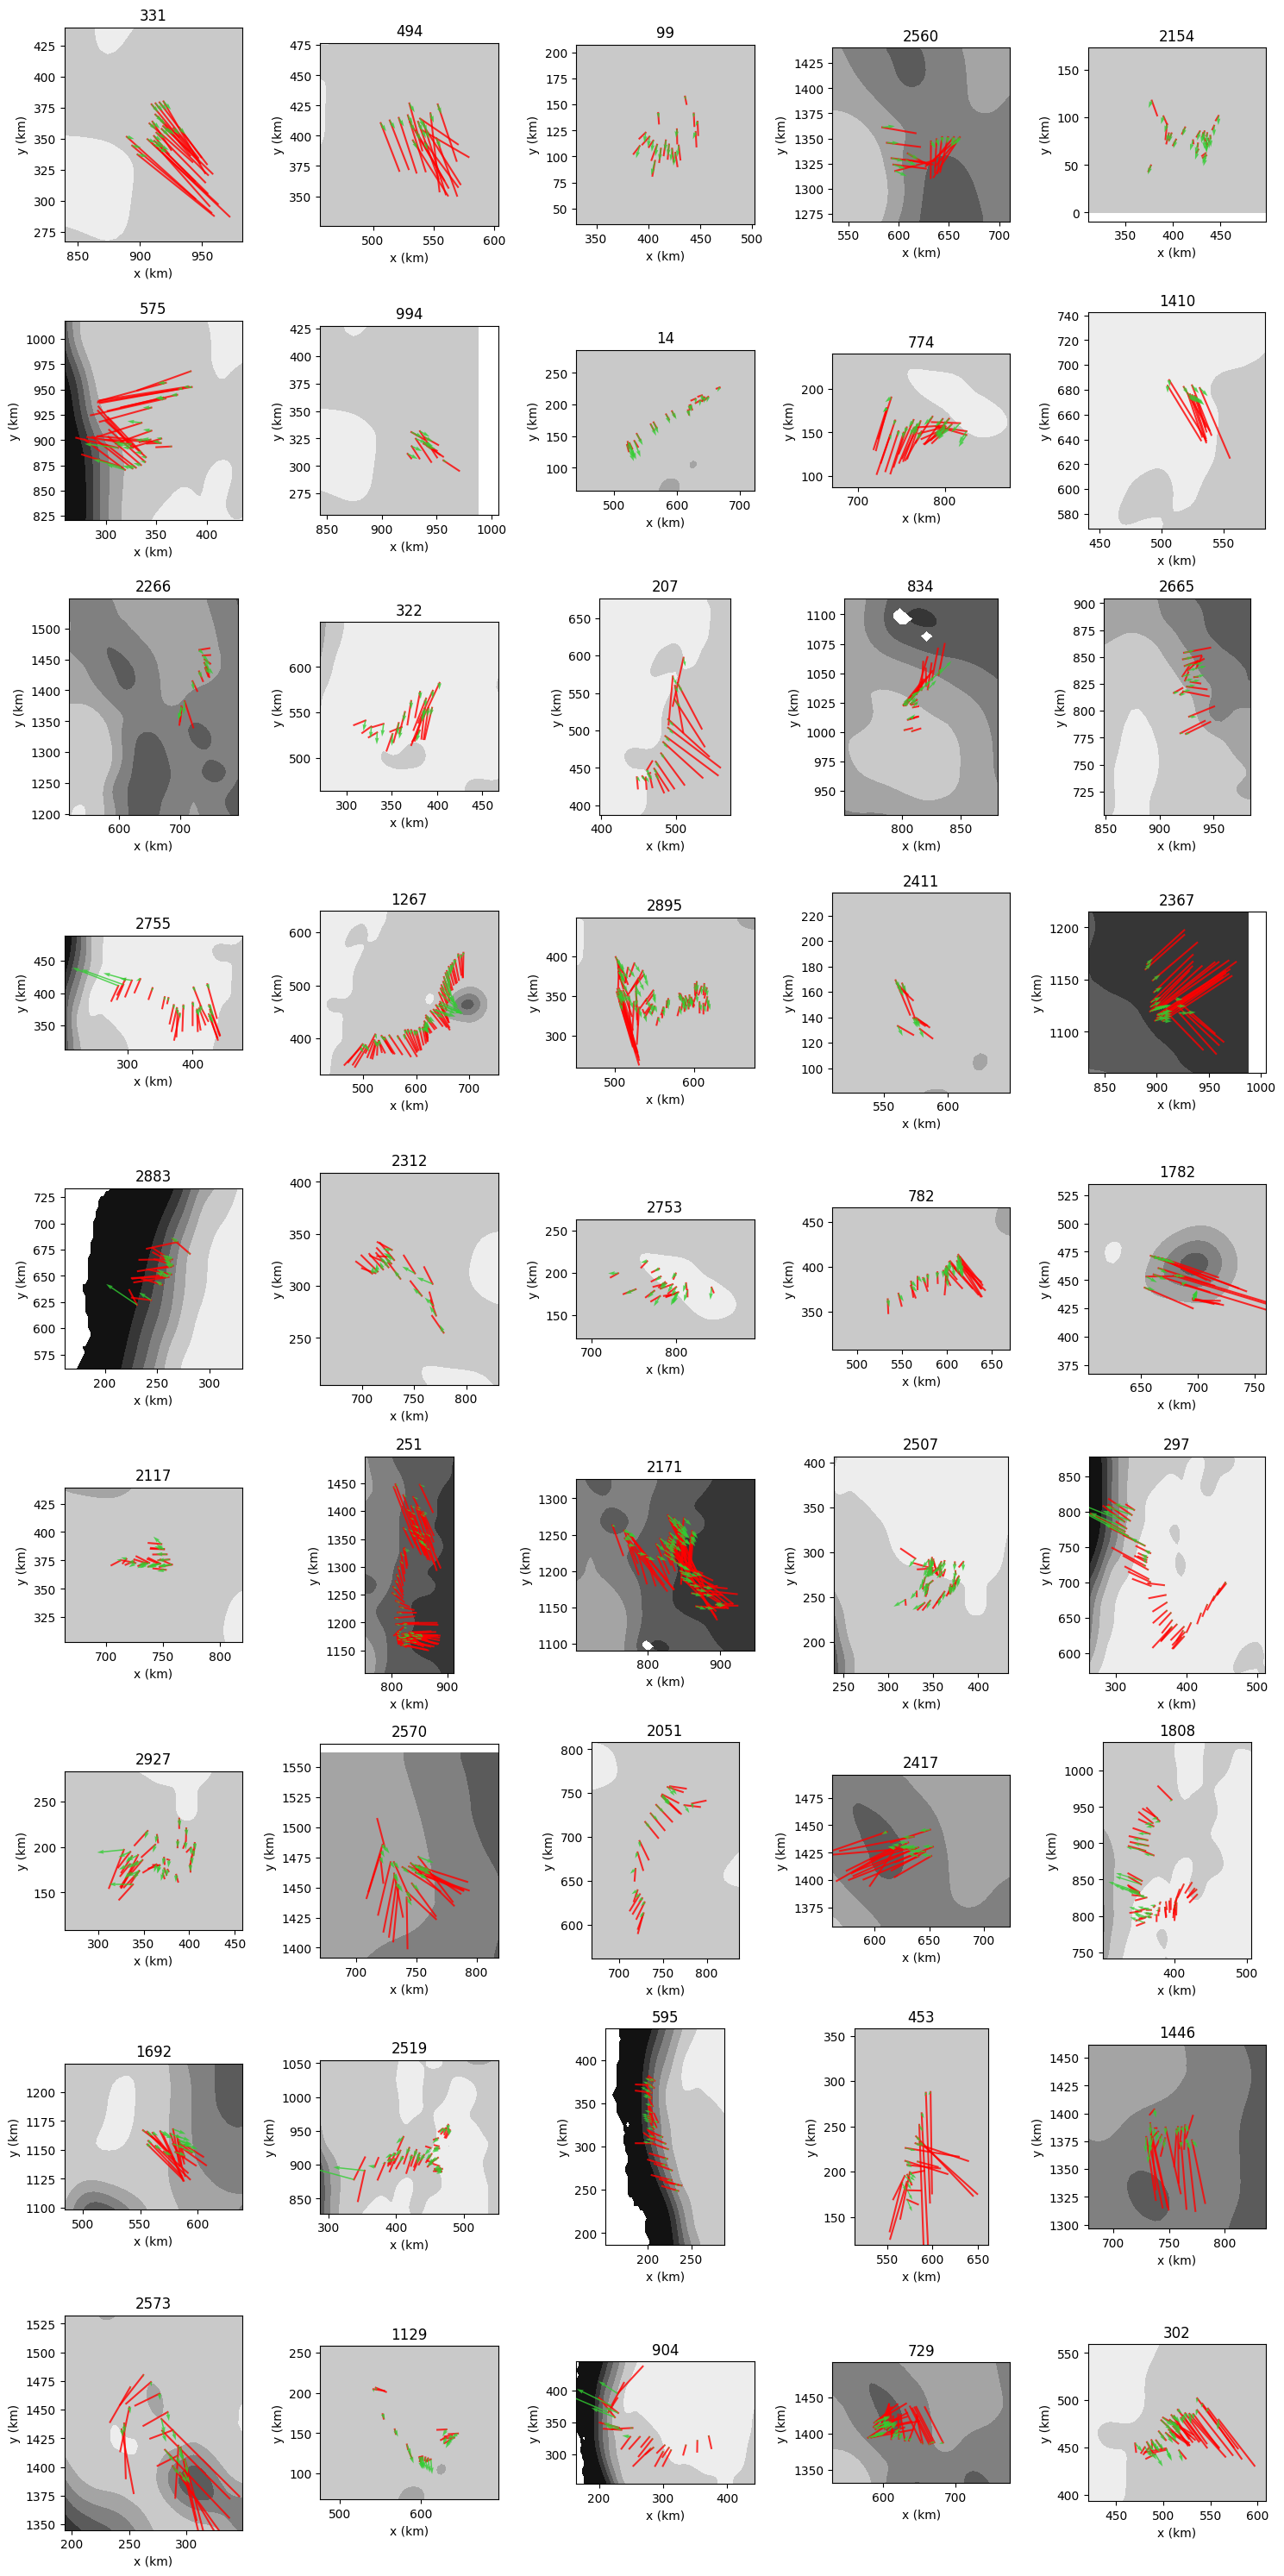

In [9]:
fig, axs = plt.subplots(9,5, figsize=(15,30))
axs = axs.flatten()
for k, eddy in enumerate(ae_top10):
    plotter(eddy, ax=axs[k])
    axs[k].set_title(eddy)
plt.tight_layout()
# plt.suptitle('high Ro')


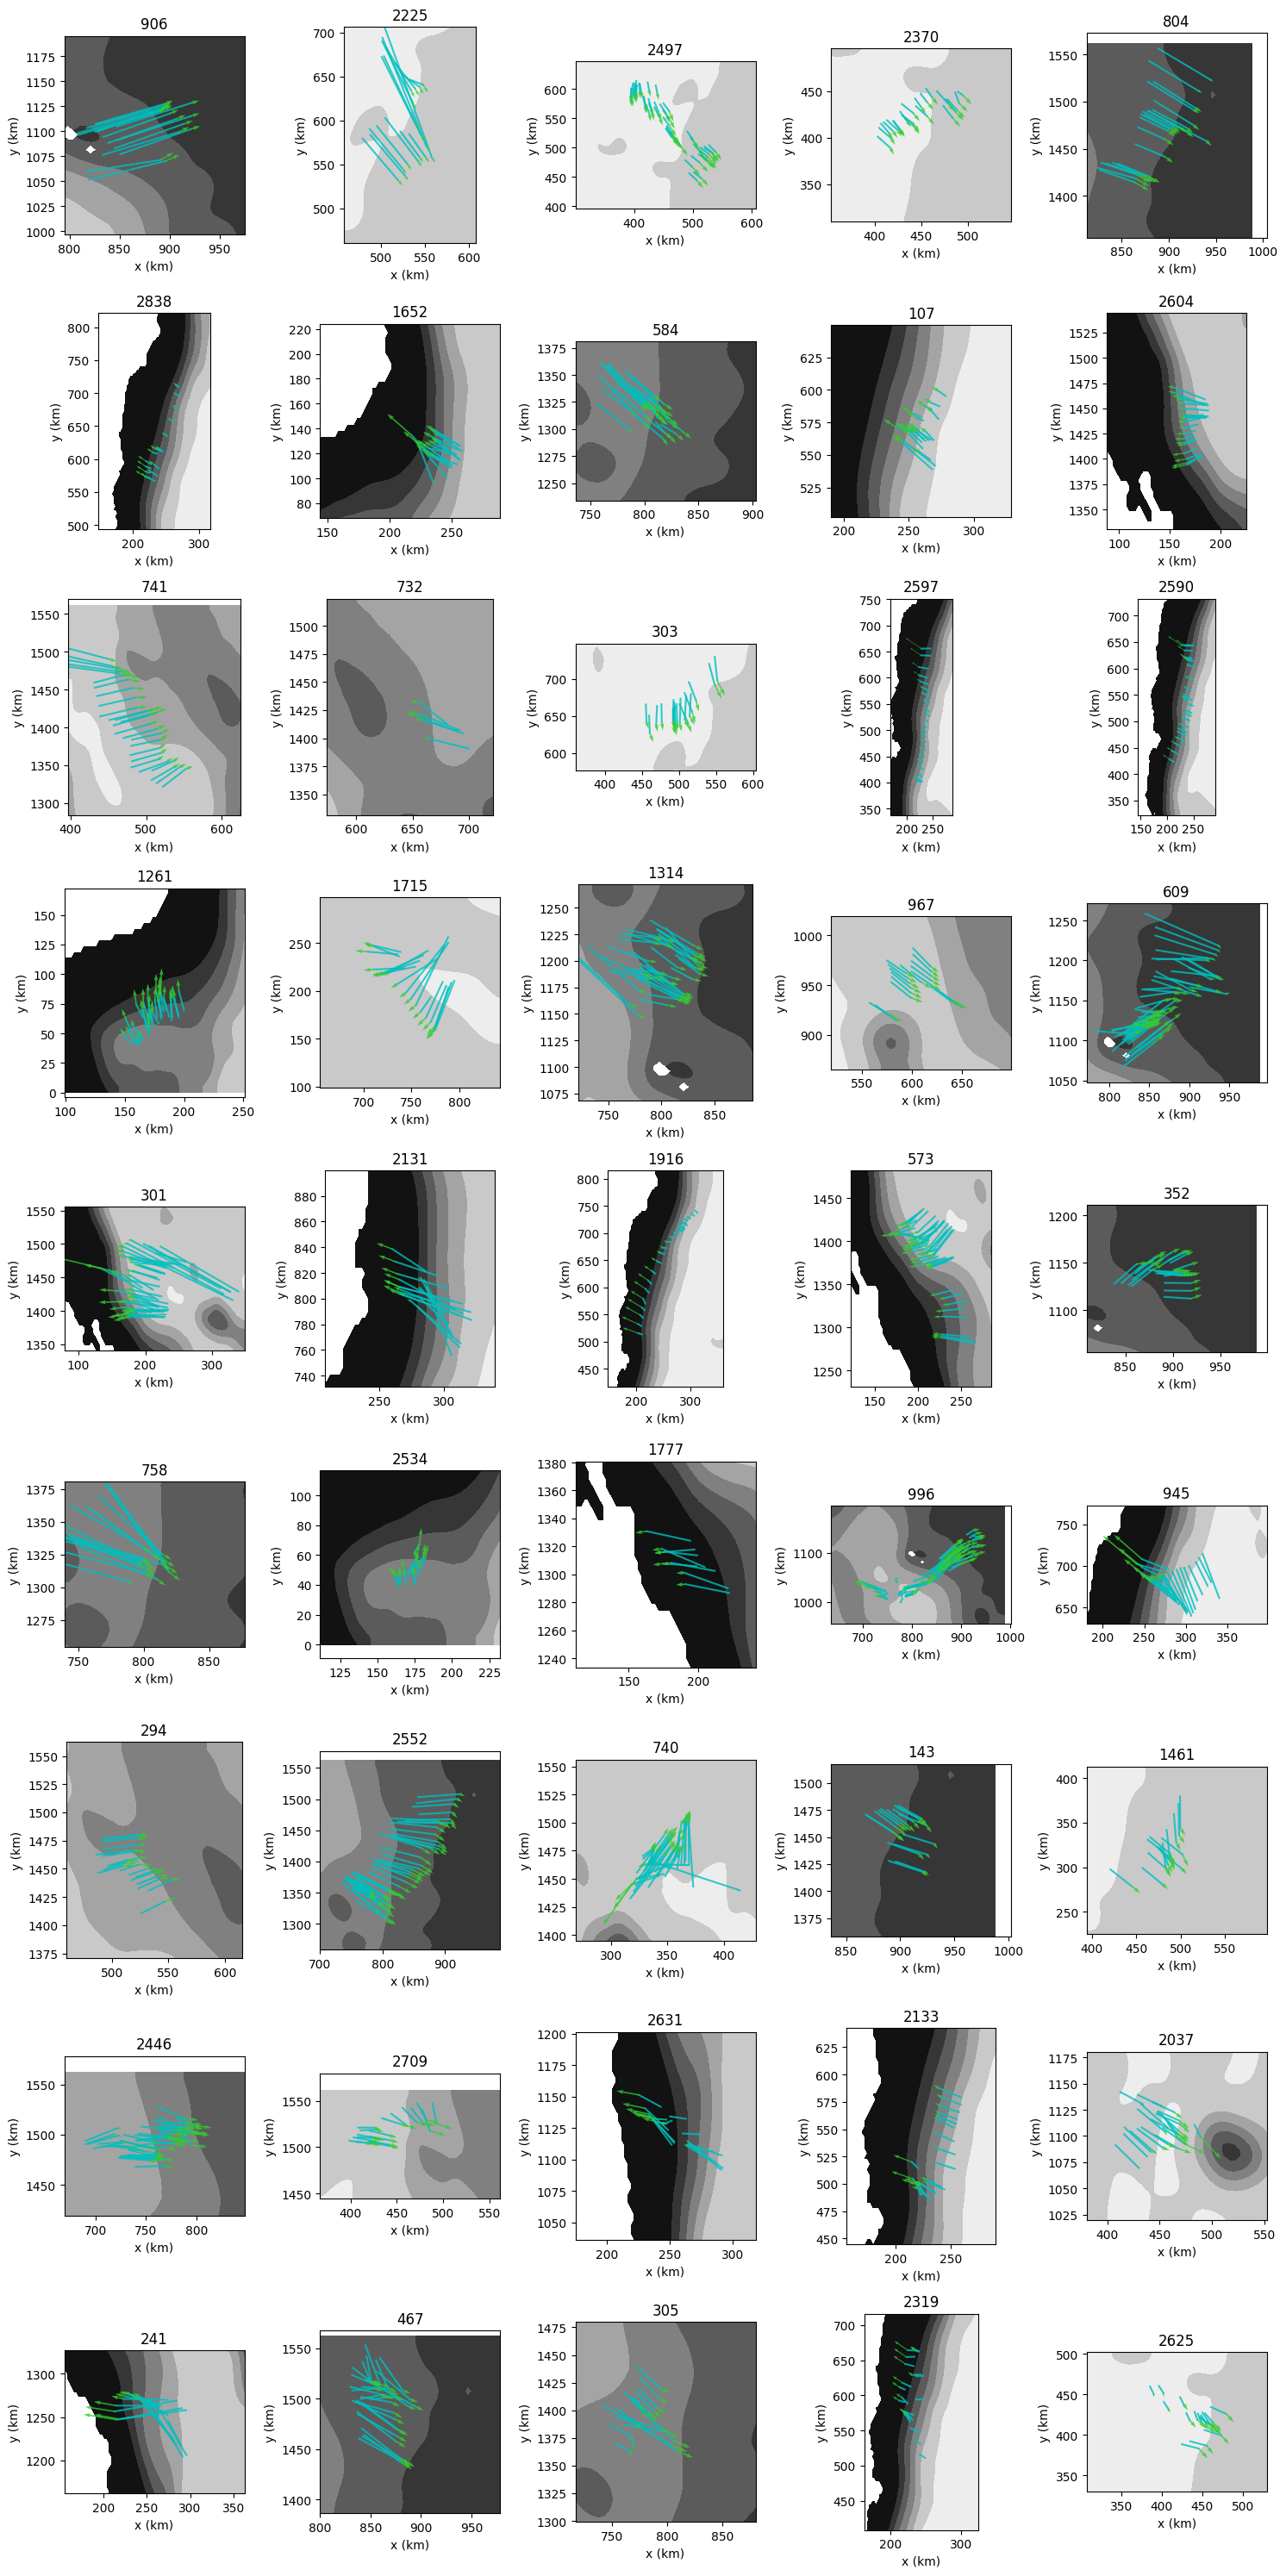

In [10]:
fig, axs = plt.subplots(9,5, figsize=(15,30))
axs = axs.flatten()
for k, eddy in enumerate(ce_top10):
    plotter(eddy, ax=axs[k])
    axs[k].set_title(eddy)
plt.tight_layout()

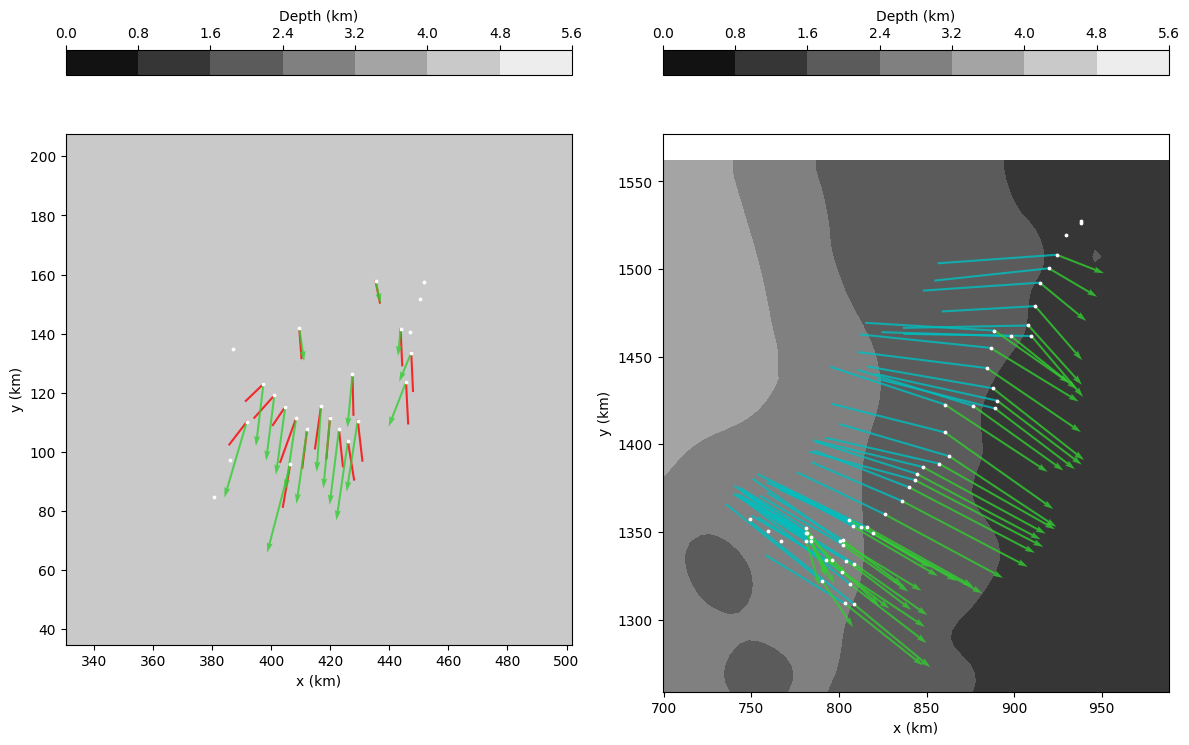

In [11]:
fig, axs = plt.subplots(1,2, figsize=(12,12))
axs = axs.flatten()
for k, eddy in enumerate([99, 2552]): #2417
    # clr = 'r' if k==0 else 'c'
    qvr_scale = .5e-13 if k==0 else 1e-12
    plotter(eddy, ax=axs[k], cbar=True, quiver_scale=qvr_scale, scatter=True, quiver_width=0.004, s=3, c='w')
    axs[k].set_title('') #eddy)
plt.tight_layout()


<module 'matplotlib.pyplot' from '/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/pyplot.py'>

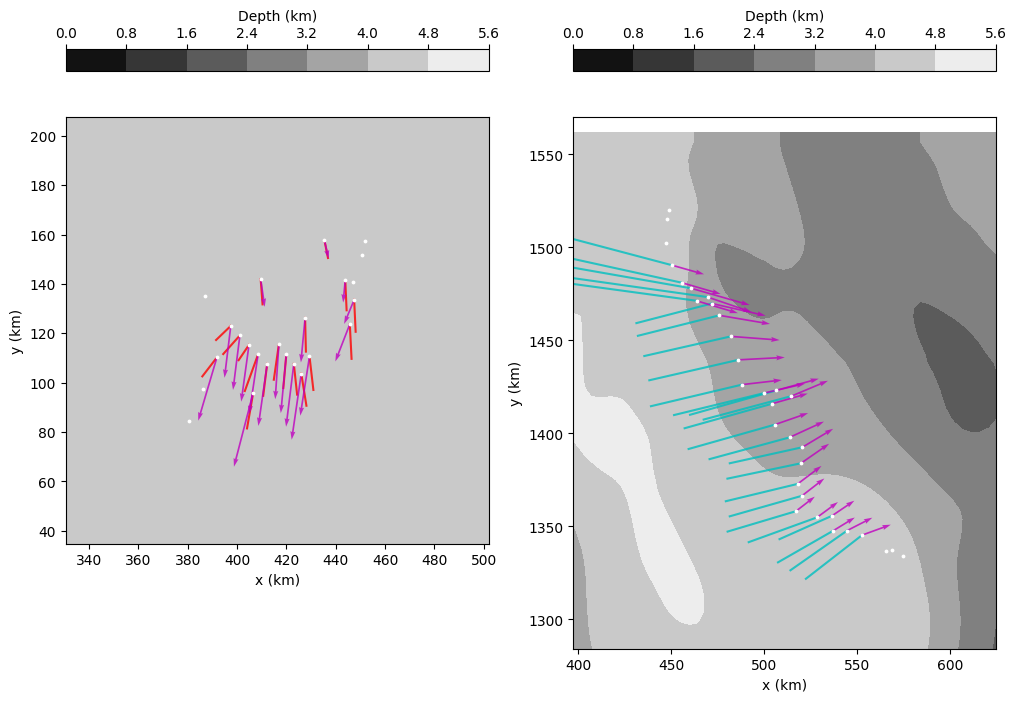

In [18]:
fig, axs = plt.subplots(1,2, figsize=(12,12))
axs = axs.flatten()
for k, eddy in enumerate([99, 741]): #2417
    # clr = 'r' if k==0 else 'c'
    qvr_scale = .5e-13 if k==0 else 1e-12
    plotter(eddy, ax=axs[k], cbar=True, quiver_scale=qvr_scale, scatter=True, quiver_width=0.004, s=3, c='w', tilt_clr='m')
    axs[k].set_title('') #eddy)
plt